# MLPro — Model Demo
Load the champion XGBoost model from MLflow, explore the dataset, score packages, and visualize SHAP explanations.

In [1]:
import sys, os
sys.path.insert(0, '../dags')

os.environ['MLFLOW_TRACKING_URI']    = 'http://localhost:5000'
os.environ['MLFLOW_S3_ENDPOINT_URL'] = 'http://localhost:9000'
os.environ['AWS_ACCESS_KEY_ID']      = 'minioadmin'
os.environ['AWS_SECRET_ACCESS_KEY']  = 'minioadmin'
os.environ['DB_HOST']  = 'localhost'
os.environ['DB_PORT']  = '5432'
os.environ['DB_NAME']  = 'packages'
os.environ['DB_USER']  = 'appuser'
os.environ['DB_PASS']  = 'apppass'

import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.xgboost
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from storage.db import get_conn

print('Libraries loaded.')

Libraries loaded.


## 1. Load the Champion Model

In [2]:
MODEL_NAME = 'malicious-package-detector'

mlflow.set_tracking_uri('http://localhost:5000')
client = mlflow.tracking.MlflowClient()

champion_mv = client.get_model_version_by_alias(MODEL_NAME, 'champion')
champion_run = client.get_run(champion_mv.run_id)
m = champion_run.data.metrics

print(f'Champion: v{champion_mv.version}')
print(f'  F1        {m["f1"]}')
print(f'  Precision {m["precision"]}')
print(f'  Recall    {m["recall"]}')
print(f'  ROC-AUC   {m["roc_auc"]}')
print(f'  Trained on {int(m["n_train"]):,} samples ({int(m["n_malicious"]):,} malicious / {int(m["n_benign"]):,} benign)')

model = mlflow.xgboost.load_model(f'models:/{MODEL_NAME}@champion')
print('\nModel loaded.')

Champion: v1
  F1        0.9995
  Precision 0.9995
  Recall    0.9995
  ROC-AUC   0.9986
  Trained on 9,287 samples (11,025 malicious / 584 benign)



Model loaded.


## 2. Pull Labeled Data from the Database

In [3]:
FEATURES = [
    'entropy_max', 'has_network_in_install', 'has_credential_access',
    'has_obfuscated_code', 'has_exec_eval', 'install_script_lines',
    'dangerous_import_count', 'has_os_targeting', 'has_external_payload',
    'api_category_count', 'typosquat_distance', 'is_typosquat',
    'has_repo_link', 'version_count', 'version_jump_suspicious',
    'description_length', 'readme_length',
]

sql = """
    SELECT
        p.name, p.registry, p.label, p.label_source,
        COALESCE(f.entropy_max, 0)                              AS entropy_max,
        COALESCE(f.has_network_in_install::int, 0)              AS has_network_in_install,
        COALESCE(f.has_credential_access::int, 0)               AS has_credential_access,
        COALESCE(f.has_obfuscated_code::int, 0)                 AS has_obfuscated_code,
        COALESCE(f.has_exec_eval::int, 0)                       AS has_exec_eval,
        COALESCE(f.install_script_lines, 0)                     AS install_script_lines,
        COALESCE(f.dangerous_import_count, 0)                   AS dangerous_import_count,
        COALESCE(f.has_os_targeting::int, 0)                    AS has_os_targeting,
        COALESCE(f.has_external_payload::int, 0)                AS has_external_payload,
        COALESCE(f.api_category_count, 0)                       AS api_category_count,
        COALESCE(f.typosquat_distance, 0)                       AS typosquat_distance,
        CASE WHEN f.typosquat_target IS NOT NULL THEN 1 ELSE 0 END AS is_typosquat,
        COALESCE(f.has_repo_link::int, 0)                       AS has_repo_link,
        COALESCE(f.version_count, 1)                            AS version_count,
        COALESCE(f.version_jump_suspicious::int, 0)             AS version_jump_suspicious,
        COALESCE(f.description_length, 0)                       AS description_length,
        COALESCE(f.readme_length, 0)                            AS readme_length
    FROM packages p
    JOIN features f ON f.package_id = p.id
    WHERE p.label IS NOT NULL
"""

with get_conn() as conn:
    df = pd.read_sql(sql, conn)

print(f'Total rows: {len(df):,}')
print(df['label'].value_counts().rename({0: 'benign', 1: 'malicious'}).to_string())
df.head(3)

Total rows: 13,340
label
malicious    11348
benign        1992


,name,registry,label,label_source,entropy_max,has_network_in_install,has_credential_access,has_obfuscated_code,has_exec_eval,install_script_lines,...,has_os_targeting,has_external_payload,api_category_count,typosquat_distance,is_typosquat,has_repo_link,version_count,version_jump_suspicious,description_length,readme_length
0,requests,pypi,0,top_pypi,5.2390,0,1,0,1,13,...,1,0,4,0,0,0,1,0,23,3034
1,typing-extensions,pypi,0,top_pypi,5.4425,0,0,1,1,0,...,0,0,3,0,0,0,1,0,54,1731
2,idna,pypi,0,top_pypi,5.3365,0,0,1,1,0,...,0,0,2,0,0,0,1,0,53,6322


## 3. Score the Entire Dataset

In [4]:
X = df[FEATURES]
y = df['label']

df['score'] = model.predict_proba(X)[:, 1]
df['predicted'] = (df['score'] >= 0.5).astype(int)

def risk(s):
    if s >= 0.8: return 'critical'
    if s >= 0.6: return 'high'
    if s >= 0.3: return 'medium'
    return 'low'

df['risk_level'] = df['score'].apply(risk)

print('Score distribution by true label:')
print(df.groupby('label')['score'].describe().round(4).to_string())

Score distribution by true label:
         count    mean     std     min     25%     50%     75%     max
label                                                                 
0       1992.0  0.0123  0.0815  0.0002  0.0005  0.0011  0.0023  0.9996
1      11348.0  0.9787  0.1130  0.0003  0.9985  0.9991  0.9993  0.9997


## 4. Score Distribution Plot

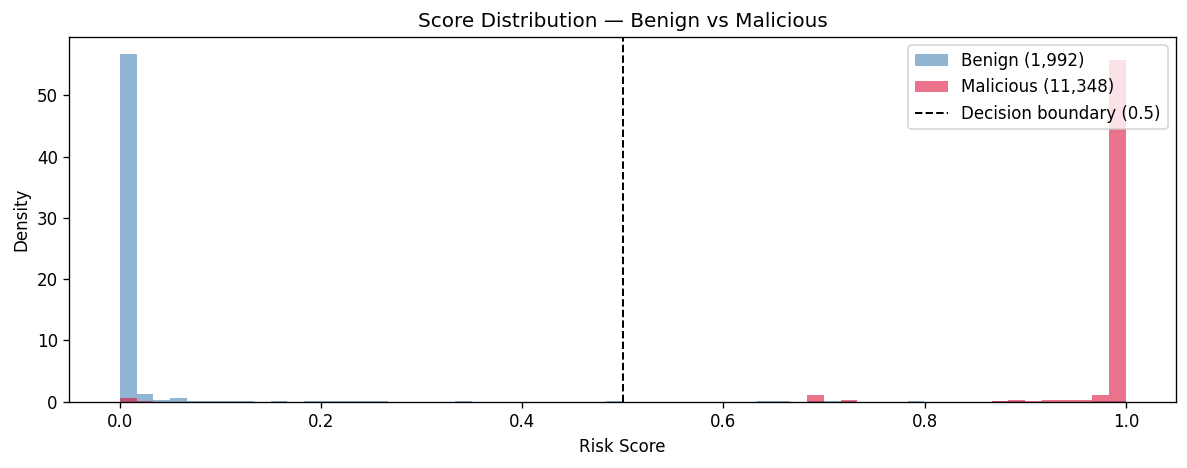

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

benign_scores    = df[df['label'] == 0]['score']
malicious_scores = df[df['label'] == 1]['score']

ax.hist(benign_scores,    bins=60, alpha=0.6, color='steelblue', label=f'Benign ({len(benign_scores):,})',    density=True)
ax.hist(malicious_scores, bins=60, alpha=0.6, color='crimson',   label=f'Malicious ({len(malicious_scores):,})', density=True)

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision boundary (0.5)')
ax.set_xlabel('Risk Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution — Benign vs Malicious')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Confusion Matrix

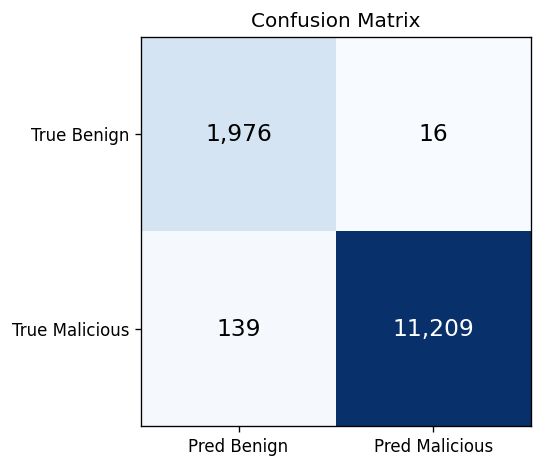

              precision    recall  f1-score   support

      benign       0.93      0.99      0.96      1992
   malicious       1.00      0.99      0.99     11348

    accuracy                           0.99     13340
   macro avg       0.97      0.99      0.98     13340
weighted avg       0.99      0.99      0.99     13340

False positives (benign flagged as malicious): 16
False negatives (malicious missed):            139


In [6]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y, df['predicted'])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Benign', 'Pred Malicious'])
ax.set_yticklabels(['True Benign', 'True Malicious'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y, df['predicted'], target_names=['benign', 'malicious']))
print(f'False positives (benign flagged as malicious): {fp}')
print(f'False negatives (malicious missed):            {fn}')

## 6. Global Feature Importance (SHAP)

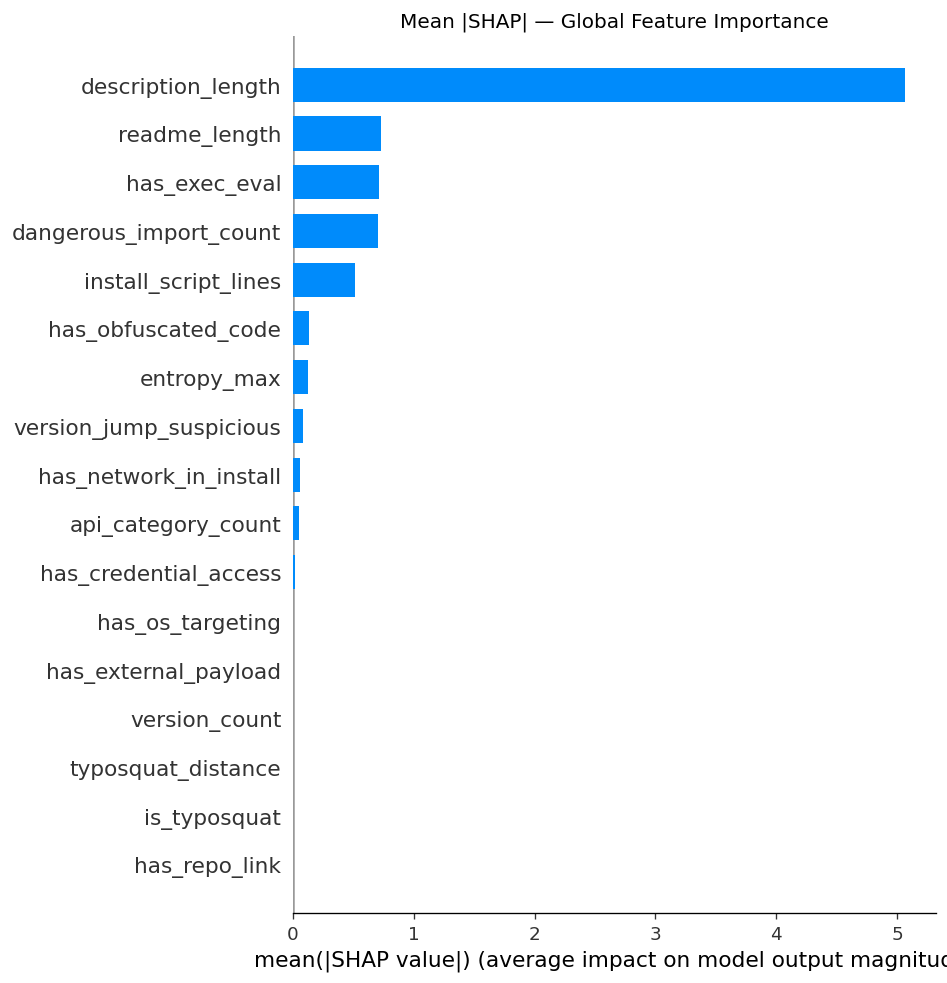

In [7]:
# Use a sample of 500 for speed
sample = X.sample(500, random_state=42)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type='bar', show=False)
plt.title('Mean |SHAP| — Global Feature Importance')
plt.tight_layout()
plt.show()

## 7. SHAP Beeswarm — How Each Feature Pushes the Score

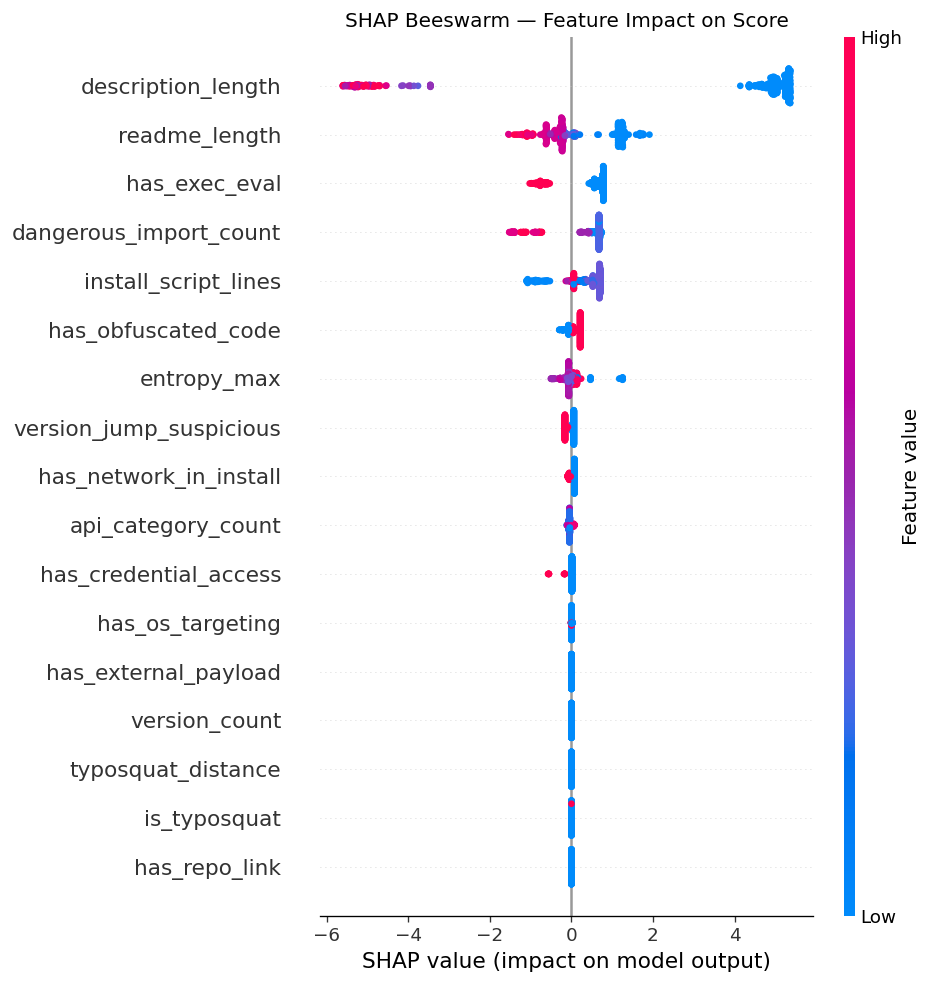

In [8]:
shap.summary_plot(shap_values, sample, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Score')
plt.tight_layout()
plt.show()

## 8. Score a Specific Malicious Package — Waterfall Plot

In [9]:
# Pick a high-scoring malicious package
evil = df[df['label'] == 1].nlargest(1, 'score').iloc[0]
print(f"Package: {evil['registry']}/{evil['name']}")
print(f"Score:   {evil['score']:.4f}  ({evil['risk_level'].upper()})")
print()

x_evil     = pd.DataFrame([evil[FEATURES]])
sv_evil    = explainer.shap_values(x_evil)[0]
shap_dict  = dict(zip(FEATURES, sv_evil))

top = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
print('Top signals:')
for feat, val in top:
    direction = '↑ raises' if val > 0 else '↓ lowers'
    print(f'  {feat:35s} {direction} risk  (SHAP {val:+.3f})')

Package: pypi/tcloud-python-sdk
Score:   0.9997  (CRITICAL)

Top signals:
  description_length                  ↑ raises risk  (SHAP +4.956)
  readme_length                       ↑ raises risk  (SHAP +1.332)
  dangerous_import_count              ↑ raises risk  (SHAP +0.710)
  has_exec_eval                       ↑ raises risk  (SHAP +0.663)
  install_script_lines                ↑ raises risk  (SHAP +0.563)
  has_obfuscated_code                 ↓ lowers risk  (SHAP -0.079)
  entropy_max                         ↑ raises risk  (SHAP +0.069)
  has_network_in_install              ↑ raises risk  (SHAP +0.068)
  version_jump_suspicious             ↑ raises risk  (SHAP +0.059)
  api_category_count                  ↓ lowers risk  (SHAP -0.051)


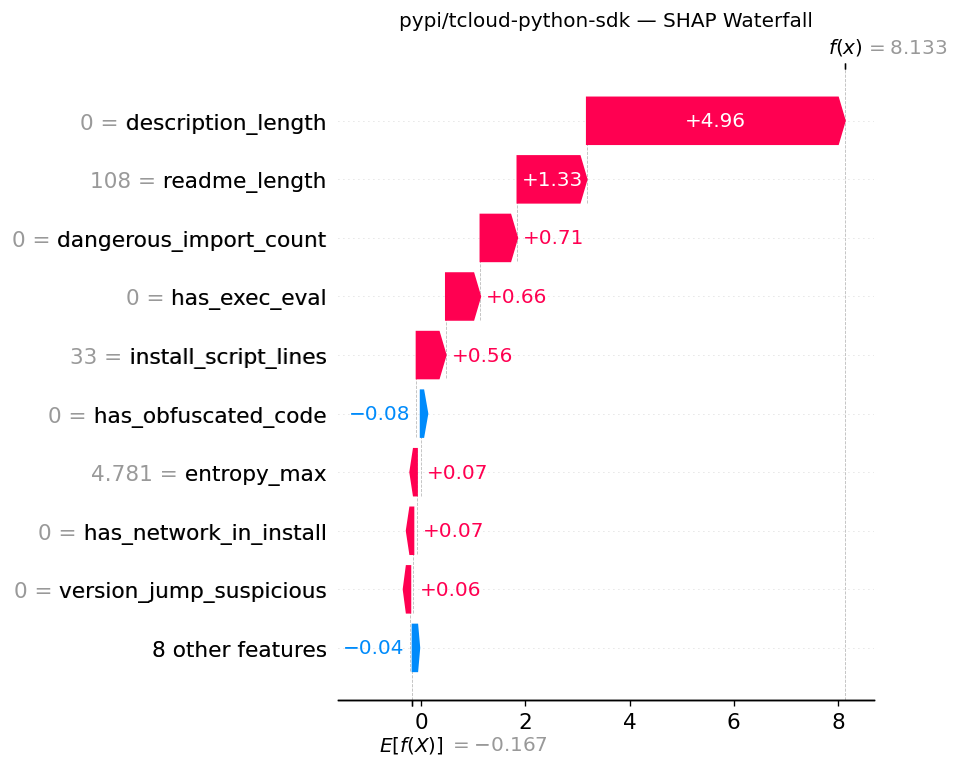

In [10]:
shap_exp = shap.Explanation(
    values        = sv_evil,
    base_values   = explainer.expected_value,
    data          = x_evil.values[0],
    feature_names = FEATURES,
)
shap.waterfall_plot(shap_exp, show=False)
plt.title(f"{evil['registry']}/{evil['name']} — SHAP Waterfall")
plt.tight_layout()
plt.show()

## 9. Score a Specific Benign Package — Waterfall Plot

Package: pypi/apache-airflow-providers-http
Score:   0.0002  (LOW)


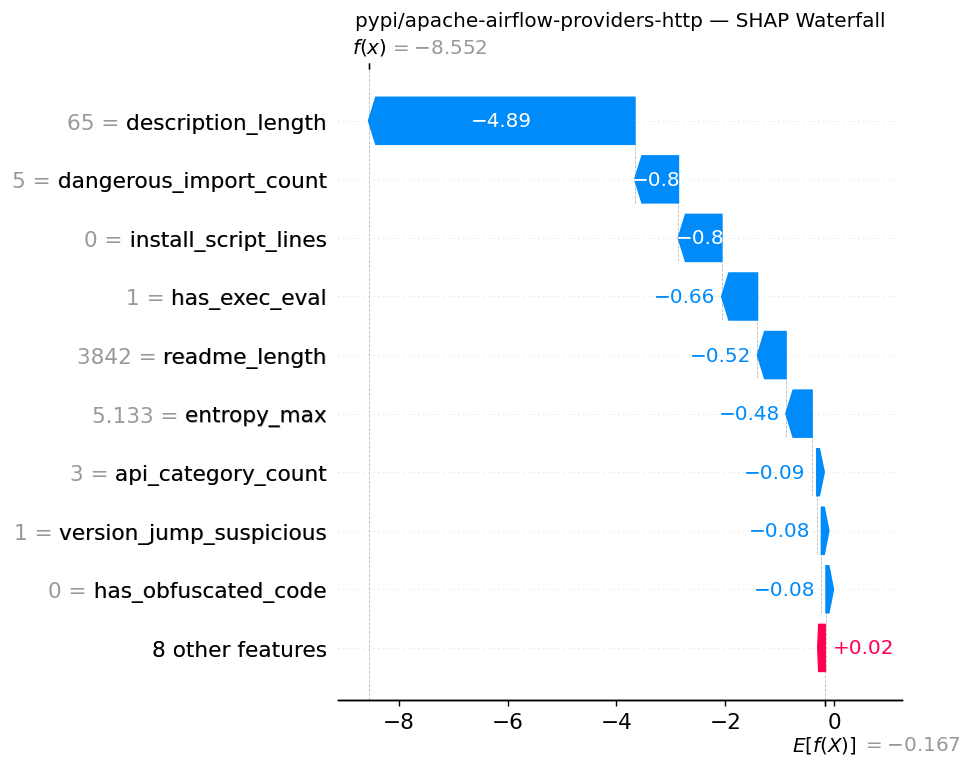

In [11]:
# Pick a well-known benign package
good = df[df['label'] == 0].nsmallest(1, 'score').iloc[0]
print(f"Package: {good['registry']}/{good['name']}")
print(f"Score:   {good['score']:.4f}  ({good['risk_level'].upper()})")

x_good  = pd.DataFrame([good[FEATURES]])
sv_good = explainer.shap_values(x_good)[0]

shap_exp_good = shap.Explanation(
    values        = sv_good,
    base_values   = explainer.expected_value,
    data          = x_good.values[0],
    feature_names = FEATURES,
)
shap.waterfall_plot(shap_exp_good, show=False)
plt.title(f"{good['registry']}/{good['name']} — SHAP Waterfall")
plt.tight_layout()
plt.show()

## 10. False Positives — Benign Packages the Model Got Wrong

In [12]:
fp_df = df[(df['label'] == 0) & (df['predicted'] == 1)].sort_values('score', ascending=False)
print(f'False positives: {len(fp_df)}')
fp_df[['name', 'registry', 'score', 'risk_level'] + FEATURES].head(10)

False positives: 16


,name,registry,score,risk_level,entropy_max,has_network_in_install,has_credential_access,has_obfuscated_code,has_exec_eval,install_script_lines,...,has_os_targeting,has_external_payload,api_category_count,typosquat_distance,is_typosquat,has_repo_link,version_count,version_jump_suspicious,description_length,readme_length
13099,simple-gcp-object-downloader,pypi,0.999646,critical,4.9208,0,0,0,0,35,...,0,0,0,0,0,0,1,0,0,0
291,safetensors,pypi,0.997264,critical,4.9422,0,0,1,0,0,...,1,0,2,0,0,0,1,0,0,0
12763,arro3-core,pypi,0.997129,critical,5.1455,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
905,jellyfish,pypi,0.991594,critical,4.9180,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,1120
12877,ag-ui-protocol,pypi,0.989272,critical,5.1032,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,2582
902,pyarrow-hotfix,pypi,0.984947,critical,5.1368,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,2532
12204,realtime,pypi,0.970569,critical,5.1133,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,5950
12317,py-spy,pypi,0.968991,critical,4.9941,0,0,0,1,24,...,1,0,4,0,0,0,1,0,0,16424
13212,obstore,pypi,0.886490,critical,5.3088,0,1,1,0,0,...,0,0,2,0,0,0,1,0,0,3020
12781,asana,pypi,0.871410,critical,5.2188,1,1,1,0,52,...,1,0,2,0,0,0,1,1,5,73477


## 11. False Negatives — Malicious Packages the Model Missed

In [13]:
fn_df = df[(df['label'] == 1) & (df['predicted'] == 0)].sort_values('score', ascending=True)
print(f'False negatives: {len(fn_df)}')
fn_df[['name', 'registry', 'score', 'risk_level'] + FEATURES].head(10)

False negatives: 139


,name,registry,score,risk_level,entropy_max,has_network_in_install,has_credential_access,has_obfuscated_code,has_exec_eval,install_script_lines,...,has_os_targeting,has_external_payload,api_category_count,typosquat_distance,is_typosquat,has_repo_link,version_count,version_jump_suspicious,description_length,readme_length
490,elementary-data,pypi,0.000293,low,5.4049,0,0,0,1,0,...,1,0,5,0,0,0,1,0,27,21772
805,axios,npm,0.000737,low,5.3226,1,0,1,1,182,...,0,0,4,0,0,0,1,0,53,90524
12052,@0xobelisk/sui-cli,npm,0.000973,low,5.2937,1,0,0,1,85,...,1,0,3,0,0,0,1,0,46,3361
980,chalk,npm,0.000979,low,5.5635,1,0,0,1,83,...,1,0,1,0,0,0,1,1,34,11690
469,convocations,pypi,0.001330,low,5.1956,1,0,1,1,103,...,1,0,5,0,0,0,1,0,12,4082
12056,@actbase/css-to-react-native-transform,npm,0.001501,low,5.1461,1,0,0,0,81,...,1,0,0,0,0,0,1,0,52,5096
525,@dev-blinq/cucumber-js,npm,0.001811,low,5.3295,1,0,0,1,201,...,1,0,4,0,0,0,1,0,202,2112
551,@ejazullah/browser-mcp,npm,0.001861,low,5.2654,1,0,1,0,93,...,1,0,2,0,0,0,1,0,75,31969
509,@ctrl/ngx-emoji-mart,npm,0.001929,low,5.0130,1,0,0,0,53,...,0,0,0,0,0,0,1,1,48,21538
610,@ensdomains/subdomain-registrar,npm,0.001941,low,5.0464,1,0,0,0,83,...,0,0,0,0,0,0,1,0,227,5442


## 12. Score Any Package by Name

In [14]:
import requests as req

def score_package(registry: str, name: str, version: str):
    resp = req.post(
        'http://localhost:8000/api/score',
        json={'registry': registry, 'name': name, 'version': version},
        timeout=30,
    )
    if resp.status_code != 200:
        print(f'Error {resp.status_code}: {resp.text}')
        return None
    d = resp.json()
    print(f"{registry}/{name}@{version}")
    print(f"  Score:      {d['score']:.4f}")
    print(f"  Risk level: {d['risk_level'].upper()}")
    print(f"  Cached:     {d['cached']}")
    print()
    print(d['report_md'])
    return d

# Try some packages from the DB
score_package('pypi', 'pluggy', '1.6.0')

pypi/pluggy@1.6.0
  Score:      0.0007
  Risk level: LOW
  Cached:     False

# pypi/pluggy@1.6.0

**Risk:** LOW  |  **Score:** 0.001

## Top signals

- **description_length**: ↓ (-5.017)
- **dangerous_import_count**: ↓ (-0.874)
- **install_script_lines**: ↓ (-0.848)
- **readme_length**: ↓ (-0.567)
- **has_exec_eval**: ↑ (+0.510)


{'registry': 'pypi',
 'name': 'pluggy',
 'version': '1.6.0',
 'score': 0.0006578655447810888,
 'risk_level': 'low',
 'report_md': '# pypi/pluggy@1.6.0\n\n**Risk:** LOW  |  **Score:** 0.001\n\n## Top signals\n\n- **description_length**: ↓ (-5.017)\n- **dangerous_import_count**: ↓ (-0.874)\n- **install_script_lines**: ↓ (-0.848)\n- **readme_length**: ↓ (-0.567)\n- **has_exec_eval**: ↑ (+0.510)',
 'model_version': '1',
 'cached': False}

In [15]:
# Try a known malicious one
score_package('npm', '000webhost-admin', '0.0.1-security')

npm/000webhost-admin@0.0.1-security
  Score:      0.7225
  Risk level: HIGH
  Cached:     True

# npm/000webhost-admin@0.0.1-security

**Risk:** HIGH  |  **Score:** 0.723

## Top signals

- **description_length**: ↓ (-3.461)
- **readme_length**: ↑ (+1.752)
- **entropy_max**: ↑ (+1.254)
- **has_exec_eval**: ↑ (+0.665)
- **dangerous_import_count**: ↑ (+0.577)


{'registry': 'npm',
 'name': '000webhost-admin',
 'version': '0.0.1-security',
 'score': 0.7225338816642761,
 'risk_level': 'high',
 'report_md': '# npm/000webhost-admin@0.0.1-security\n\n**Risk:** HIGH  |  **Score:** 0.723\n\n## Top signals\n\n- **description_length**: ↓ (-3.461)\n- **readme_length**: ↑ (+1.752)\n- **entropy_max**: ↑ (+1.254)\n- **has_exec_eval**: ↑ (+0.665)\n- **dangerous_import_count**: ↑ (+0.577)',
 'model_version': '1',
 'cached': True}